---
# Building Traditional RAG Using ChromaDB Vector Store

---

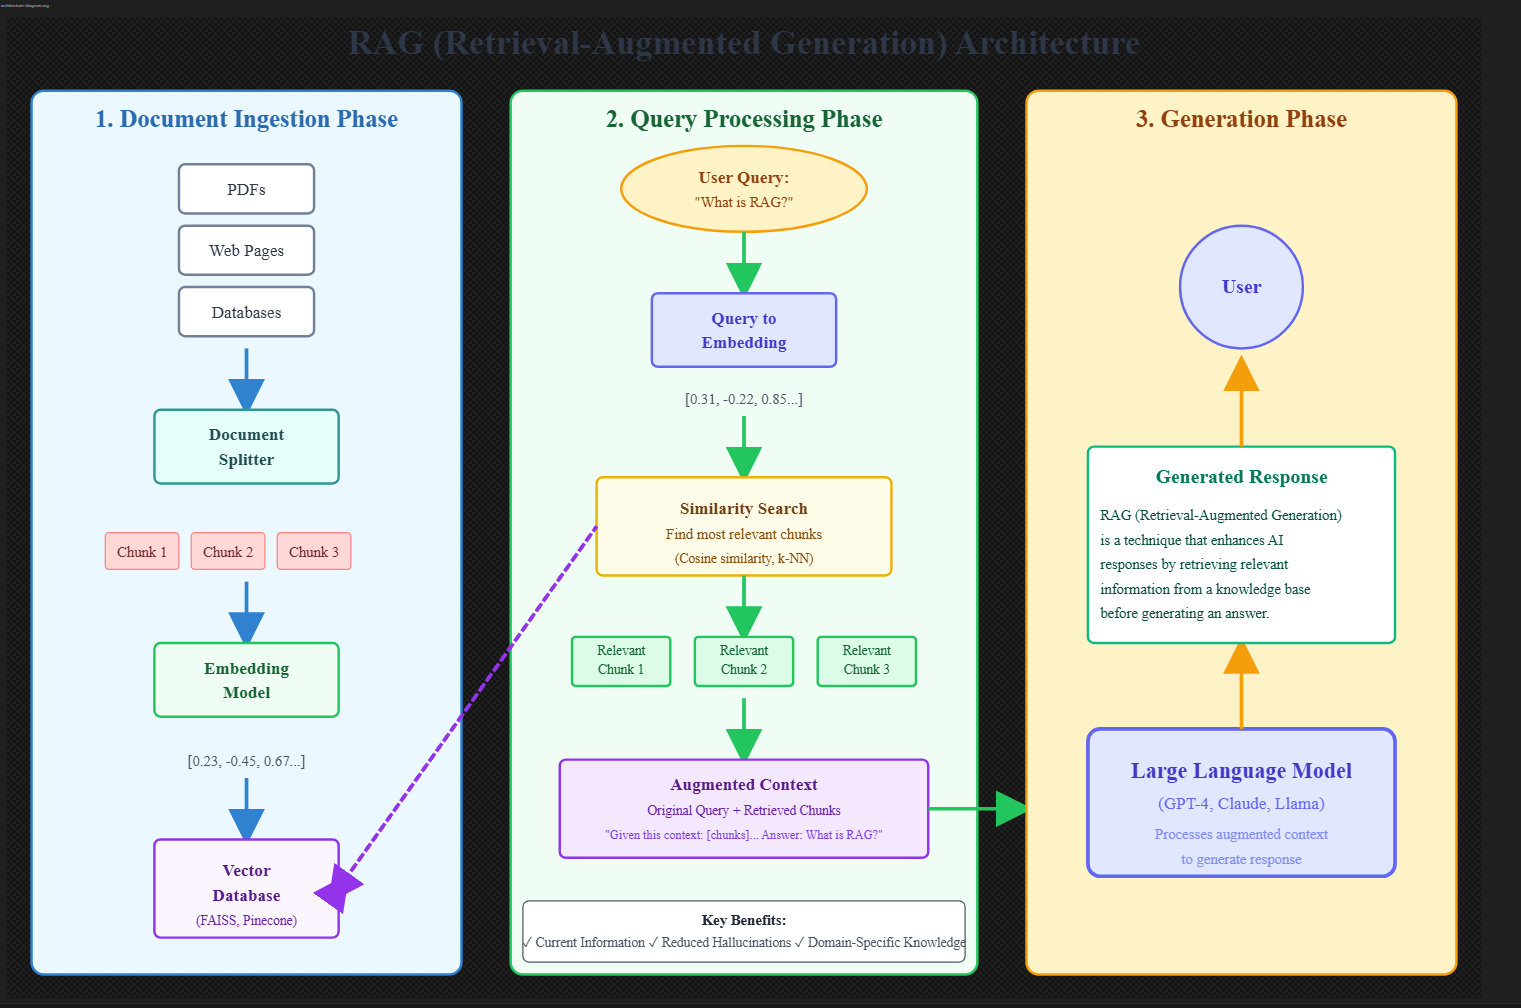

---

## Building a RAG System with LangChain and ChromaDB
### Introduction
`Retrieval-Augmented Generation (RAG)` is a powerful technique that combines the capabilities of large language models with external knowledge retrieval. This notebook will walk you through building a complete RAG system using:

- **LangChain**: A framework for developing applications powered by language models
- **ChromaDB**: An open-source vector database for storing and retrieving embeddings
- **OpenAI**: For embeddings and language model (you can substitute with other providers)

----

#### Load `.env` file

In [3]:
# Load dotenv file
import os 
from dotenv import load_dotenv
load_dotenv()

True

----

#### Langchain Libraries

In [1]:
# Langchain imports
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_community.document_loaders import TextLoader
from langchain_openai import OpenAIEmbeddings
from langchain.schema import Document
from langchain_core.documents import Document

# Vectorstores
from langchain_community.vectorstores import Chroma

# Utility imports
import numpy as np
from typing import List 

---

#### RAG Architecture Overview

In [4]:
# RAG Architecture Overview
print("""
RAG (Retrieval-Augmented Generation) Architecture:

1. Document Loading: Load documents from various sources
2. Document Splitting: Break documents into smaller chunks
3. Embedding Generation: Convert chunks into vector representations
4. Vector Storage: Store embeddings in ChromaDB
5. Query Processing: Convert user query to embedding
6. Similarity Search: Find relevant chunks from vector store
7. Context Augmentation: Combine retrieved chunks with query
8. Response Generation: LLM generates answer using context

Benefits of RAG:
- Reduces hallucinations
- Provides up-to-date information
- Allows citing sources
- Works with domain-specific knowledge
""")


RAG (Retrieval-Augmented Generation) Architecture:

1. Document Loading: Load documents from various sources
2. Document Splitting: Break documents into smaller chunks
3. Embedding Generation: Convert chunks into vector representations
4. Vector Storage: Store embeddings in ChromaDB
5. Query Processing: Convert user query to embedding
6. Similarity Search: Find relevant chunks from vector store
7. Context Augmentation: Combine retrieved chunks with query
8. Response Generation: LLM generates answer using context

Benefits of RAG:
- Reduces hallucinations
- Provides up-to-date information
- Allows citing sources
- Works with domain-specific knowledge



---

#### 1. Sample Data

In [5]:
# Create sample documents
sample_docs = [
    """
    Machine Learning Fundamentals
    
    Machine learning is a subset of artificial intelligence that enables systems to learn 
    and improve from experience without being explicitly programmed. There are three main 
    types of machine learning: supervised learning, unsupervised learning, and reinforcement 
    learning. Supervised learning uses labeled data to train models, while unsupervised 
    learning finds patterns in unlabeled data. Reinforcement learning learns through 
    interaction with an environment using rewards and penalties.
    """,
    
    """
    Deep Learning and Neural Networks
    
    Deep learning is a subset of machine learning based on artificial neural networks. 
    These networks are inspired by the human brain and consist of layers of interconnected 
    nodes. Deep learning has revolutionized fields like computer vision, natural language 
    processing, and speech recognition. Convolutional Neural Networks (CNNs) are particularly 
    effective for image processing, while Recurrent Neural Networks (RNNs) and Transformers 
    excel at sequential data processing.
    """,
    
    """
    Natural Language Processing (NLP)
    
    NLP is a field of AI that focuses on the interaction between computers and human language. 
    Key tasks in NLP include text classification, named entity recognition, sentiment analysis, 
    machine translation, and question answering. Modern NLP heavily relies on transformer 
    architectures like BERT, GPT, and T5. These models use attention mechanisms to understand 
    context and relationships between words in text.
    """
]

sample_docs


['\n    Machine Learning Fundamentals\n\n    Machine learning is a subset of artificial intelligence that enables systems to learn \n    and improve from experience without being explicitly programmed. There are three main \n    types of machine learning: supervised learning, unsupervised learning, and reinforcement \n    learning. Supervised learning uses labeled data to train models, while unsupervised \n    learning finds patterns in unlabeled data. Reinforcement learning learns through \n    interaction with an environment using rewards and penalties.\n    ',
 '\n    Deep Learning and Neural Networks\n\n    Deep learning is a subset of machine learning based on artificial neural networks. \n    These networks are inspired by the human brain and consist of layers of interconnected \n    nodes. Deep learning has revolutionized fields like computer vision, natural language \n    processing, and speech recognition. Convolutional Neural Networks (CNNs) are particularly \n    effective f

In [7]:
len(sample_docs)

3

`tempfile.mkdtemp()` in Python is a function that creates a temporary directory and returns the path to it as a string.

In [6]:
# Save Sample file documents to files
import tempfile

temp_dir = tempfile.mkdtemp()

for i,doc in enumerate(sample_docs):
    with open(f"{temp_dir}/doc_{i}.txt", "w") as f:
        f.write(doc)

print(f"Sample document create in : {temp_dir}")

Sample document create in : C:\Users\Satish\AppData\Local\Temp\tmp85hl8x4t


In [8]:
temp_dir

'C:\\Users\\Satish\\AppData\\Local\\Temp\\tmp85hl8x4t'

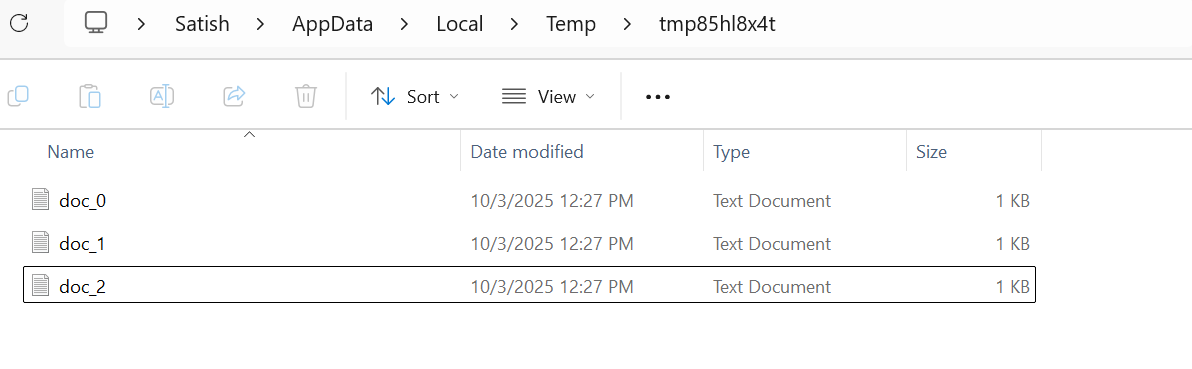 <br><br> 
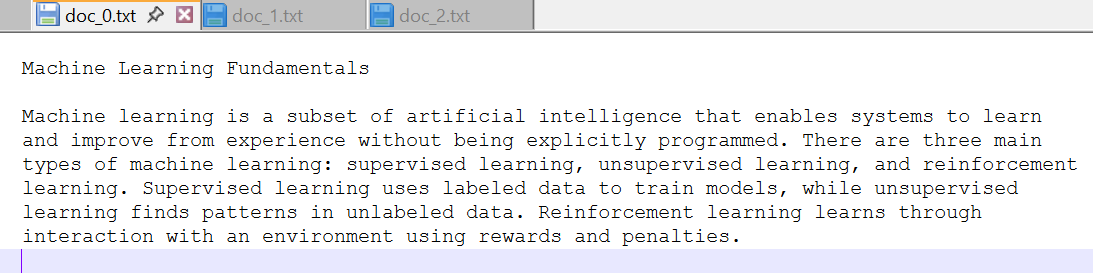 <br><br>
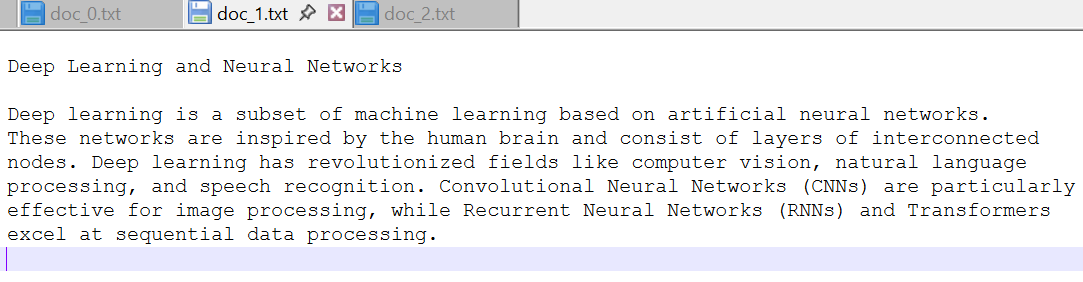 <br><br>
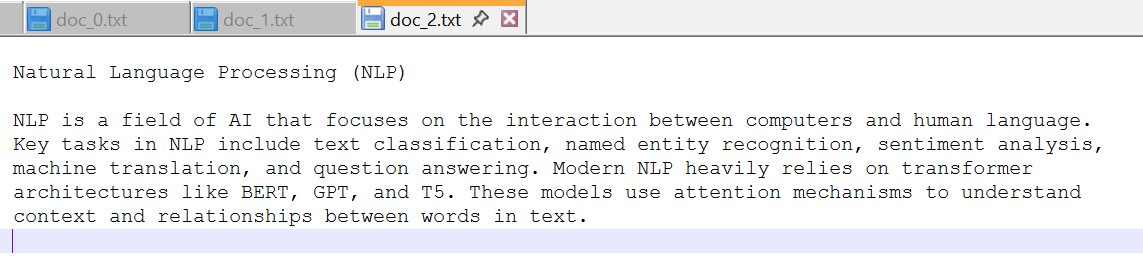 <br><br>

In [15]:
import os
os.makedirs("data", exist_ok=True)

for i,doc in enumerate(sample_docs):
    with open(f"data/doc_{i}.txt", "w") as f:
        f.write(doc)

print(f"Sample document create")

Sample document create


---

#### 2. Document Loading

In [17]:
from langchain_community.document_loaders import DirectoryLoader, TextLoader

# Load dcouments from directory
loader = DirectoryLoader(
    temp_dir,
    glob="*.txt",
    loader_cls=TextLoader,
    loader_kwargs={'encoding': 'utf-8'}
)
documents = loader.load()

print(f"Loaded {len(documents)} documents")
print(f"\nFirst document preview:")
print(documents[0].page_content[:200] + ".....")
print(f"\nSecond document preview:")
print(documents[1].page_content[:200] + ".....")
print(f"\nThird document preview:")
print(documents[2].page_content[:200] + ".....")


Loaded 3 documents

First document preview:

    Machine Learning Fundamentals

    Machine learning is a subset of artificial intelligence that enables systems to learn 
    and improve from experience without being explicitly programmed. Ther.....

Second document preview:

    Deep Learning and Neural Networks

    Deep learning is a subset of machine learning based on artificial neural networks. 
    These networks are inspired by the human brain and consist of layers.....

Third document preview:

    Natural Language Processing (NLP)

    NLP is a field of AI that focuses on the interaction between computers and human language. 
    Key tasks in NLP include text classification, named entity r.....


In [18]:
documents

[Document(metadata={'source': 'C:\\Users\\Satish\\AppData\\Local\\Temp\\tmp85hl8x4t\\doc_0.txt'}, page_content='\n    Machine Learning Fundamentals\n\n    Machine learning is a subset of artificial intelligence that enables systems to learn \n    and improve from experience without being explicitly programmed. There are three main \n    types of machine learning: supervised learning, unsupervised learning, and reinforcement \n    learning. Supervised learning uses labeled data to train models, while unsupervised \n    learning finds patterns in unlabeled data. Reinforcement learning learns through \n    interaction with an environment using rewards and penalties.\n    '),
 Document(metadata={'source': 'C:\\Users\\Satish\\AppData\\Local\\Temp\\tmp85hl8x4t\\doc_1.txt'}, page_content='\n    Deep Learning and Neural Networks\n\n    Deep learning is a subset of machine learning based on artificial neural networks. \n    These networks are inspired by the human brain and consist of layers of

---